<a href="https://colab.research.google.com/github/jhonegonzalezq/opti-bio/blob/main/REVIEW_DOCTORADO3103.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install bertopic
!pip install sentence-transformers ==5.2.0
!pip install umap-learn==0.5.9.post2
!pip install hdbscan
!pip install nltk
!pip install spacy
!pip install bibtexparser
!pip install scikit-learn
!pip install pybibx
!pip install tabulate
!pip install datasets==4.0.0
!pip install safetensors==0.7.0
!pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio

ERROR: Invalid requirement: '==5.2.0': Expected package name at the start of dependency specifier
    ==5.2.0
    ^
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for bibtexparser: filename=bibtexparser-1.4.4-py3-none-any.whl size=43609 sha256=cb15caef6701086922b649f5e59dba7fa0785849e05a164df909358891cb2a65
  Stored in directory: /root/.cache/pip/wheels/54/f8/e6/ecfceb6af875ddc5096bb3811795ac336f50371009a601454d
Successfully built bibtexparser
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.6/117.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 334.3/334.3 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 78.5 MB/s e

In [2]:
import pandas as pd
import numpy as np
import textwrap
import bibtexparser
import re
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import data_table
from tabulate import tabulate
from prettytable import PrettyTable
from pybibx.base import pbx_probe

In [3]:
# Arguments: file_bib = 'filename.bib'; db = 'scopus', 'wos', 'pubmed'; del_duplicated = True, False
file_name = 'scopus31031912.bib'
database  = 'scopus';
bibfile   = pbx_probe(file_bib = file_name, db = database, del_duplicated = True)

A Total of 1910 Documents were Found ( 1912 Documents and 2 Duplicates )

Article = 1910


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Health Analysis
health = bibfile.health_bib()

# Check Health
health

,Entries,Completeness (%),Number of Docs
0,Sources,100.00%,1910
1,Abstracts,99.90%,1908
2,Affiliation,100.00%,1910
3,Author(s),100.00%,1910
4,DOI,96.34%,1840
5,Keywords - Authors,90.94%,1737
6,Keywords - Plus,84.29%,1610
7,References,0.00%,0
8,Year,100.00%,1910


In [6]:
# Generate EDA (Exploratory Data Analysis) Report
report  = bibfile.eda_bib()

# Check Report
report

,Main Information,Results
0,Timespan,2000-2026
1,Total Number of Countries,111
2,Total Number of Institutions,2457
3,Total Number of Sources,541
4,Total Number of References,0
5,Total Number of Languages,1
6,--english (# of docs),1910
7,-//-,-//-
8,Total Number of Documents,1910
9,--Article,1910


In [7]:
# The metadata can be reviewed and manually modified. If you need to make adjustments, you can directly edit the bibfile.data, which is a DataFrame containing all the utilized information.
print(tabulate(bibfile.data.head(n = 10), headers = 'keys', tablefmt = 'psql'))
# Modify 'bibfile.data' as needed.

+----+-------------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [8]:
# The metadata can be reviewed and manually modified. If you need to make adjustments, you can directly edit the bibfile.data, which is a DataFrame containing all the utilized information.
print(tabulate(bibfile.data.head(n = 10), headers = 'keys', tablefmt = 'psql'))
# Modify 'bibfile.data' as needed.

+----+-------------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

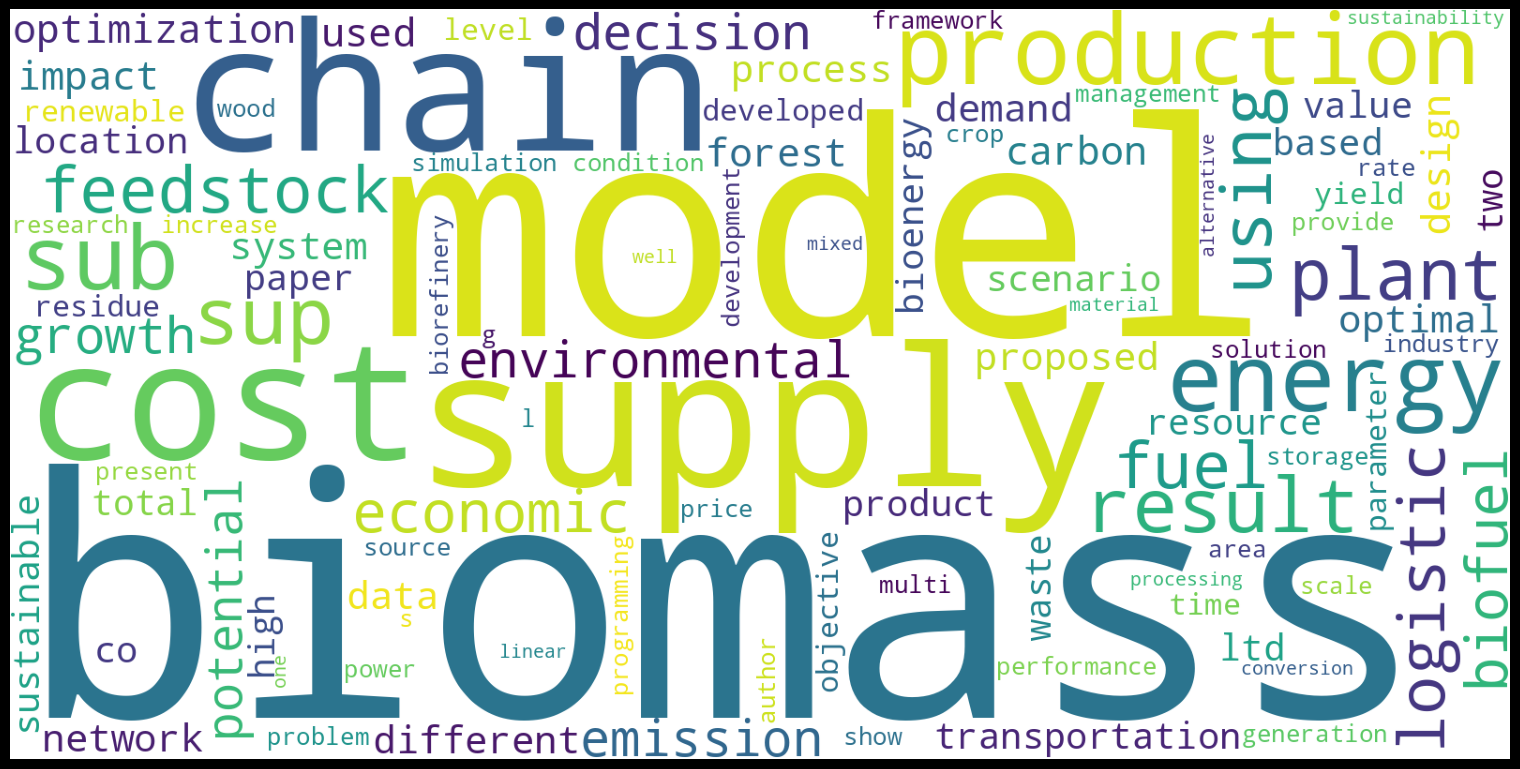

In [9]:
# WordCloud from the Abstracts, Title, Authors Keywords or Keywords Plus
# Arguments: entry             = 'abs', 'title', 'kwa', or 'kwp'
#            rmv_custom_words  = A list of custom stopwords to clean the corpus;
bibfile.word_cloud_plot(entry = 'abs', size_x = 15, size_y = 10, wordsn = 100, rmv_custom_words = ["a", "about", "above", "after", "again", "against", "ain", "al", "all", "am", "an", "análisis", "analysis", "and", "any", "application", "approach", "are", "aren", "aren't", "article", "as", "at", "based", "basado", "be", "because", "been", "before", "being", "below", "between", "both", "but", "by", "can", "case", "caso", "con", "copyright", "couldn", "couldn't", "d", "de", "did", "didn", "didn't", "do", "does", "doesn", "doesn't", "doing", "doi", "don", "don't", "down", "during", "each", "efecto", "effect", "el", "elsevier", "en", "enfoque", "estudio", "evaluation", "few", "for", "from", "further", "ga", "had", "hadn", "hadn't", "has", "hasn", "hasn't", "have", "haven", "haven't", "having", "he", "he'd", "he'll", "he's", "her", "here", "hers", "herself", "him", "himself", "his", "how", "http", "i", "i'd", "i'll", "i'm", "i've", "if", "in", "inf", "into", "is", "isn", "isn't", "it", "it'd", "it'll", "it's", "its", "itself", "just", "la", "las", "ll", "los", "m", "ma", "me", "method", "metodología", "mightn", "mightn't", "more", "most", "mustn", "mustn't", "my", "myself", "needn", "needn't", "no", "nor", "not", "now", "o", "of", "off", "on", "once", "only", "or", "other", "our", "ours", "ourselves", "out", "over", "own", "para", "pdf", "por", "re", "reserved", "rights", "s", "same", "shan", "shan't", "she", "she'd", "she'll", "she's", "should", "should've", "shouldn", "shouldn't", "so", "some", "springer", "study", "such", "system", "t", "than", "that", "that'll", "the", "their", "theirs", "them", "themselves", "then", "there", "these", "they", "they'd", "they'll", "they're", "they've", "this", "those", "through", "to", "too", "un", "una", "under", "unknown", "until", "up", "use", "uso", "ve", "very", "was", "wasn", "wasn't", "we", "we'd", "we'll", "we're", "we've", "were", "weren", "weren't", "what", "when", "where", "which", "while", "who", "whom", "why", "will", "with", "won", "won't", "wouldn", "wouldn't", "y", "you", "you'd", "you'll", "you're", "your", "yours", "yourself", "yourselves"])

In [10]:
# Documents Projection based on Words. (An interactive plot). It returns the Projection (each document coordinate) and the Labels (each document cluster)
# Arguments: view              = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            corpus_type       = 'abs', 'title', 'kwa', or 'kwp';
#            stop_words        = A list of stopwords to clean the corpus. ['ar', 'bn', 'bg', 'cs', 'en', 'fi', 'fr', 'de', 'el', 'hi', 'he', 'hu', 'it', 'ja', 'ko',  'mr', 'fa', 'pl', 'pt-br', 'ro', 'ru', 'es', 'sv', 'sk', 'zh', 'th', 'uk'];
#                                'ar' = Arabic; 'bn' = Bengali; 'bg' = Bulgarian; 'cs' = Czech; 'en' = English; 'fi' = Finnish; 'fr' = French; 'de' = German; 'el' = Greek; 'he' = Hebrew;'hi' = Hindi; 'hu' = Hungarian; 'it' = Italian;
#                                'ja' = Japanese; 'ko' = Korean; 'mr' =  Marathi; 'fa' =  Persian; 'pl' =  Polish; 'pt-br' = Potuguese-Brazilian; 'ro' = Romanian; 'ru' = Russian; 'es' =  Spanish; 'sk' = Slovak; 'sv' = Swedish;
#                                'zh' = Chinese; 'th' = Thai; 'uk' = Ukrainian
#            rmv_custom_words  = A list of custom stopwords to clean the corpus;
#            custom_label      = A list of custom labels for each document. The user can define each document cluster;
#            custom_projection = A list of custom coordinates for each document. The user can define each document coordinate;
#            n_components      = Number of Dimensions;
#            n_clusters        = Only relevant if  cluster_method = 'kmeans'.Number of Clusters.;
#            node_labels       = If True, labels appear in nodes;
#            node_size         = Node size;
#            node_font_size    = Node font size;
#            tf_idf            = True or False (True -> The Cluster Algorithm will use the DTM to calculate each document Label. False -> The Cluster Algorithm will use the Coordinates to calculate each document Label);
#            embeddings        = True or False (True -> The Cluster Algorithm will use the Word Embeddings to calculate each document Label. False -> The Cluster Algorithm will use the Coordinates to calculate each document Label);
#            model             = Only relevant if 'embeddings = True'. Specifies the used AI model. The default value is 'allenai/scibert_scivocab_uncased';
#            method            = 'tsvd' or 'umap' ('tsvd' -> Truncated SVD projection method is used. 'umap' -> UMAP projection method is used);
#            showlegend        = If True, shows legend;
#            cluster_method    = 'kmeans' or 'hdbscan';
#            min_size          = Only relevant if  cluster_method = 'hdbscan'. Minimum number of elements in a Cluster;
#            max_size          = Only relevant if  cluster_method = 'hdbscan'. Maximum number of elements in a Cluster
projection, labels = bibfile.docs_projection(view              = 'notebook',
                                             corpus_type       = 'kwp',
                                             stop_words        = ['en'],
                                             rmv_custom_words  = ["a", "about", "above", "after", "again", "against", "ain", "al", "all", "am", "an", "análisis", "analysis", "and", "any", "application", "approach", "are", "aren", "aren't", "article", "as", "at", "based", "basado", "be", "because", "been", "before", "being", "below", "between", "both", "but", "by", "can", "case", "caso", "con", "copyright", "couldn", "couldn't", "d", "de", "did", "didn", "didn't", "do", "does", "doesn", "doesn't", "doing", "doi", "don", "don't", "down", "during", "each", "efecto", "effect", "el", "elsevier", "en", "enfoque", "estudio", "evaluation", "few", "for", "from", "further", "ga", "had", "hadn", "hadn't", "has", "hasn", "hasn't", "have", "haven", "haven't", "having", "he", "he'd", "he'll", "he's", "her", "here", "hers", "herself", "him", "himself", "his", "how", "http", "i", "i'd", "i'll", "i'm", "i've", "if", "in", "inf", "into", "is", "isn", "isn't", "it", "it'd", "it'll", "it's", "its", "itself", "just", "la", "las", "ll", "los", "m", "ma", "me", "method", "metodología", "mightn", "mightn't", "more", "most", "mustn", "mustn't", "my", "myself", "needn", "needn't", "no", "nor", "not", "now", "o", "of", "off", "on", "once", "only", "or", "other", "our", "ours", "ourselves", "out", "over", "own", "para", "pdf", "por", "re", "reserved", "rights", "s", "same", "shan", "shan't", "she", "she'd", "she'll", "she's", "should", "should've", "shouldn", "shouldn't", "so", "some", "springer", "study", "such", "system", "t", "than", "that", "that'll", "the", "their", "theirs", "them", "themselves", "then", "there", "these", "they", "they'd", "they'll", "they're", "they've", "this", "those", "through", "to", "too", "un", "una", "under", "unknown", "until", "up", "use", "uso", "ve", "very", "was", "wasn", "wasn't", "we", "we'd", "we'll", "we're", "we've", "were", "weren", "weren't", "what", "when", "where", "which", "while", "who", "whom", "why", "will", "with", "won", "won't", "wouldn", "wouldn't", "y", "you", "you'd", "you'll", "you're", "your", "yours", "yourself", "yourselves"],
                                             custom_label      = [],
                                             custom_projection = [],
                                             n_components      = 2,
                                             n_clusters        = 8,
                                             node_labels       = True,
                                             node_size         = 12,
                                             node_font_size    = 5,
                                             tf_idf            = False,
                                             embeddings        = False,
                                             model             = 'allenai/scibert_scivocab_uncased',
                                             method            = 'umap',
                                             showlegend        = True,
                                             cluster_method    = 'hdbscan',
                                             min_size          = 5,
                                             max_size          = 50
                                             )

In [11]:
# Check Articles per Cluster
cluster      = 3
idx_articles = [i for i in range(0, labels.shape[0]) if labels[i] == cluster]
print(*idx_articles, sep = ', ')
# Contar cuántos documentos hay en ese cluster
print("Número de documentos en el clúster", cluster, ":", len(idx_articles))

326, 375, 377, 412, 766, 1051, 1252, 1677, 1733, 1748, 1817, 1908
Número de documentos en el clúster 3 : 12


In [12]:
# Arguments: view              = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            key               = 'abs', 'title', 'jou, 'kwa', or 'kwp';
#            stop_words        = A list of stopwords to clean the corpus. ['ar', 'bn', 'bg', 'cs', 'en', 'fi', 'fr', 'de', 'el', 'hi', 'he', 'hu', 'it', 'ja', 'ko',  'mr', 'fa', 'pl', 'pt-br', 'ro', 'ru', 'es', 'sv', 'sk', 'zh', 'th', 'uk'];
#                                'ar' = Arabic; 'bn' = Bengali; 'bg' = Bulgarian; 'cs' = Czech; 'en' = English; 'fi' = Finnish; 'fr' = French; 'de' = German; 'el' = Greek; 'he' = Hebrew;'hi' = Hindi; 'hu' = Hungarian; 'it' = Italian;
#                                'ja' = Japanese; 'ko' = Korean; 'mr' =  Marathi; 'fa' =  Persian; 'pl' =  Polish; 'pt-br' = Potuguese-Brazilian; 'ro' = Romanian; 'ru' = Russian; 'es' =  Spanish; 'sk' = Slovak; 'sv' = Swedish;
#                                'zh' = Chinese; 'th' = Thai; 'uk' = Ukrainian
#            rmv_custom_words  = A list of custom stopwords to clean the corpus;
#            topn              = Total number entities;
#            txt_font_size     = Font size of the text inside the bins;
#            start             = Start Year; -1 = all years
#            end               = End Year;   -1 = all years
bibfile.plot_evolution_year(view             = 'notebook',
                            stop_words       = [],
                            rmv_custom_words = ["a", "about", "above", "after", "again", "against", "ain", "al", "all", "am", "an", "análisis", "analysis", "and", "any", "application", "approach", "are", "aren", "aren't", "article", "as", "at", "based", "basado", "be", "because", "been", "before", "being", "below", "between", "both", "but", "by", "can", "case", "caso", "con", "copyright", "couldn", "couldn't", "d", "de", "did", "didn", "didn't", "do", "does", "doesn", "doesn't", "doing", "doi", "don", "don't", "down", "during", "each", "efecto", "effect", "el", "elsevier", "en", "enfoque", "estudio", "evaluation", "few", "for", "from", "further", "ga", "had", "hadn", "hadn't", "has", "hasn", "hasn't", "have", "haven", "haven't", "having", "he", "he'd", "he'll", "he's", "her", "here", "hers", "herself", "him", "himself", "his", "how", "http", "i", "i'd", "i'll", "i'm", "i've", "if", "in", "inf", "into", "is", "isn", "isn't", "it", "it'd", "it'll", "it's", "its", "itself", "just", "la", "las", "ll", "los", "m", "ma", "me", "method", "metodología", "mightn", "mightn't", "more", "most", "mustn", "mustn't", "my", "myself", "needn", "needn't", "no", "nor", "not", "now", "o", "of", "off", "on", "once", "only", "or", "other", "our", "ours", "ourselves", "out", "over", "own", "para", "pdf", "por", "re", "reserved", "rights", "s", "same", "shan", "shan't", "she", "she'd", "she'll", "she's", "should", "should've", "shouldn", "shouldn't", "so", "some", "springer", "study", "such", "system", "t", "than", "that", "that'll", "the", "their", "theirs", "them", "themselves", "then", "there", "these", "they", "they'd", "they'll", "they're", "they've", "this", "those", "through", "to", "too", "un", "una", "under", "unknown", "until", "up", "use", "uso", "ve", "very", "was", "wasn", "wasn't", "we", "we'd", "we'll", "we're", "we've", "were", "weren", "weren't", "what", "when", "where", "which", "while", "who", "whom", "why", "will", "with", "won", "won't", "wouldn", "wouldn't", "y", "you", "you'd", "you'll", "you're", "your", "yours", "yourself", "yourselves"],
                            key              = 'kwp',
                            topn             = 10,
                            txt_font_size    = 12,
                            start            = 2000,
                            end              = 2026)

In [13]:
# View Table
data_ep = bibfile.ask_gpt_ep
print(textwrap.fill(data_ep, 150))

 2000: biomass (5), nonhuman (4), mathematical models (4), growth kinetics (4), bioreactors (3), fungi (3), fungus growth (3), glucose (2), growth
rate (2), biological (2) 2001: biomass (2), economic analysis (1), cost benefit analysis (1), wood (1), alternative energy (1), energy efficiency (1),
power generation (1), energy utilization (1), gasification (1), growth (1) 2002: biomass (7), nonhuman (3), mathematical models (3), kinetics (2),
models (2), controlled study (2), mathematical model (2), growth (2), bioreactors (2), fungi (2) 2003: biomass (3), nonhuman (2), growth rate (2),
fermentation (1), models (1), biomass power (1), mathematical models (1), simulation (1), priority journal (1), glucose (1) 2004: biomass (5),
mathematical models (5), picea (3), regression analysis (2), forestry (2), bacterial growth (2), defoliation (2), prediction (2), nonhuman (2), weed
control (2) 2005: biomass (11), mathematical models (8), fermentation (4), world (4), ecology (3), parameter estimat

In [14]:
# Arguments: view              = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn              = Most frequent n words
#            custom            = Plot specific words
bibfile.plot_evolution_year_complement(data_ep, view = 'notebook', topn = 10, custom = [])

In [15]:
# Arguments:
#   view         : Determines the rendering mode.'notebook' -> Plots in your preferred Notebook app. 'browser'  -> Plots in your preferred browser window.
#   entry        : A list defining the sequence of data columns to be visualized. Allowed keys: 'aut', 'cout', 'inst', 'jou', 'kwa', 'kwp', 'lan'
#   rmv_unknowns : Boolean flag controlling how unknown entries are handled. True  -> Remove any relationships that include 'unknown'.
#   topn         : Specifies the maximum number of top entities/connections to display at each level. Set to "None" for no filtering or provide a list with limits corresponding to each connection between the nodes defined in 'entry'.
bibfile.sankey_diagram(view = 'notebook', entry = ['cout', 'aut', 'kwp'], topn = [10, 2], rmv_unknowns = True)

In [16]:
# Countries Productivity Plot (An interactive plot). It informs the production for each Country (count is made considering each doc author)
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
bibfile.countries_productivity(view = 'notebook')

In [17]:
# View Table
data_cp = bibfile.ask_gpt_cp
data_table.DataTable(data_cp, num_rows_per_page = 15)

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2018,2019,2020,2021,2022,2023,2024,2025,2026,All Years
united states of america,4,2,0,5,6,9,16,11,17,34,...,107,90,111,113,100,82,71,137,64,1705
china,0,0,0,0,6,2,18,3,3,0,...,46,49,28,32,84,67,153,186,43,847
india,0,0,0,0,1,0,0,3,4,7,...,11,30,11,52,11,45,56,63,17,399
canada,3,0,0,1,3,0,4,5,3,3,...,18,32,21,27,40,26,20,19,9,364
italy,0,0,3,0,0,1,7,0,6,7,...,32,17,16,15,27,12,22,18,0,321
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
congo,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
mozambique,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
luxembourg,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
uzbekistan,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1


In [25]:
# Tree Map
# Arguments: view          = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            entry         = 'kwp', 'kwa', 'aut', 'jou', 'ctr', or 'inst';
#            topn          = Total number entities
#            txt_font_size = Font size of the text inside the bins;
bibfile.tree_map(view = 'notebook', entry = 'jou', topn = 10)

In [24]:
# Authors Productivity Plot (An interactive plot). It informs for each year the documents (IDs) published for each author
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn = Total number entities
bibfile.authors_productivity(view = 'notebook', topn = 10)

In [23]:
# View Table
data_ap = bibfile.ask_gpt_ap
data_table.DataTable(data_ap, num_rows_per_page = 10)

,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
"lam, hon loong",0.0,0.0,0.0,0.0,1.0,2.0,0.0,4.0,1.0,2.0,...,3.0,6.0,2.0,2.0,1.0,1.0,3.0,0.0,1.0,0.0
"sowlati, taraneh",0.0,0.0,0.0,1.0,0.0,2.0,0.0,3.0,4.0,0.0,...,0.0,2.0,3.0,3.0,1.0,1.0,2.0,0.0,2.0,0.0
"ponce-ortega, josé maría",0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,2.0,2.0,...,4.0,1.0,1.0,0.0,1.0,3.0,0.0,0.0,1.0,1.0
"how, bing shen",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,4.0,2.0,2.0,2.0,2.0,3.0,0.0,0.0,0.0
"you, fengqi",0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,6.0,3.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"sokhansanj, shahab",1.0,1.0,0.0,1.0,1.0,2.0,0.0,2.0,1.0,0.0,...,3.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
"shah, nilay",0.0,0.0,1.0,2.0,0.0,2.0,2.0,1.0,2.0,1.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
"marufuzzaman, mohammad",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,...,1.0,1.0,2.0,0.0,2.0,1.0,0.0,0.0,0.0,2.0
"bezzo, fabrizio",0.0,0.0,0.0,2.0,1.0,3.0,2.0,3.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"sahebi, hadi",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,2.0,2.0,2.0,1.0,2.0,1.0,1.0,0.0


In [22]:
# Institutions Productivity Plot (An interactive plot). It informs for each year the documents (IDs) published for each institution
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn = Total number entities
bibfile.institution_productivity(view = 'notebook', topn = 10)

In [26]:
# View Table
data_ip = bibfile.ask_gpt_ip
data_table.DataTable(data_ip, num_rows_per_page = 10)

,2000,2003,2006,2007,2008,2009,2010,2011,2012,2013,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
university of british columbia,0.0,0.0,1.0,1.0,0.0,1.0,1.0,2.0,0.0,3.0,...,4.0,3.0,5.0,3.0,1.0,3.0,3.0,0.0,3.0,0.0
mississippi state university,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,1.0,...,2.0,1.0,2.0,0.0,3.0,1.0,1.0,1.0,0.0,3.0
north dakota state university,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,4.0,...,2.0,1.0,2.0,3.0,1.0,1.0,3.0,1.0,1.0,0.0
university of tennessee,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,...,0.0,2.0,1.0,2.0,2.0,1.0,0.0,1.0,0.0,2.0
university of illinois at urbana-champaign,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,2.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
iran university of science and technology,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,5.0,1.0,3.0,3.0,3.0,2.0,1.0,2.0,0.0
oak ridge national laboratory,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,0.0,1.0,...,4.0,2.0,1.0,0.0,1.0,2.0,1.0,0.0,2.0,0.0
north carolina state university,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,2.0,2.0,1.0,3.0,3.0,0.0
university of tehran,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,0.0,4.0,2.0,2.0,1.0,4.0,1.0,2.0
university of california,0.0,1.0,1.0,0.0,1.0,1.0,3.0,2.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [28]:
# Bar Plots
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#                    statistic = 'dpy', 'cpy', 'ppy', 'ltk', 'spd', 'spc', 'apd', 'apc', 'aph', 'bdf_1', 'bdf_2', 'bdf_3', 'ipd', 'ipc', 'cpd', 'cpc', 'lpd', 'kpd', 'kad'
#                        'dpy' = Documents per Year
#                         cpy' = Citations per Year
#                        'ppy' = Past Citations per Year
#                        'ltk' = Lotka's Law
#                        'spd' = Sources per Documents
#                        'spc' = Sources per Citations
#                        'apd' = Authors per Documents
#                        'apc' = Authors per Citations
#                        'aph' = Authors per H-Index
#                        'bdf_1', 'bdf_2', 'bdf_3' = Bradford's Law - Core Sources 1, 2 or 3
#                        'ipd' = Institutions per Documents
#                        'ipc' = Institutions per Citations
#                        'cpd' = Countries per Documents
#                        'cpc' = Countries per Citations
#                        'lpd' = Language per Documents
#                        'kpd' = Keywords Plus per Documents
#                        'kad' = Authors' Keywords per Documents
#                         topn = Total number entities
bibfile.plot_bars(view = 'notebook', statistic = 'dpy', topn = 10)

In [29]:
# View Table
data_bp = bibfile.ask_gpt_bp
data_table.DataTable(data_bp, num_rows_per_page = 10)

,Year,Documents
0,2000,7
1,2001,4
2,2002,9
3,2003,7
4,2004,8
5,2005,12
6,2006,25
7,2007,14
8,2008,18
9,2009,30


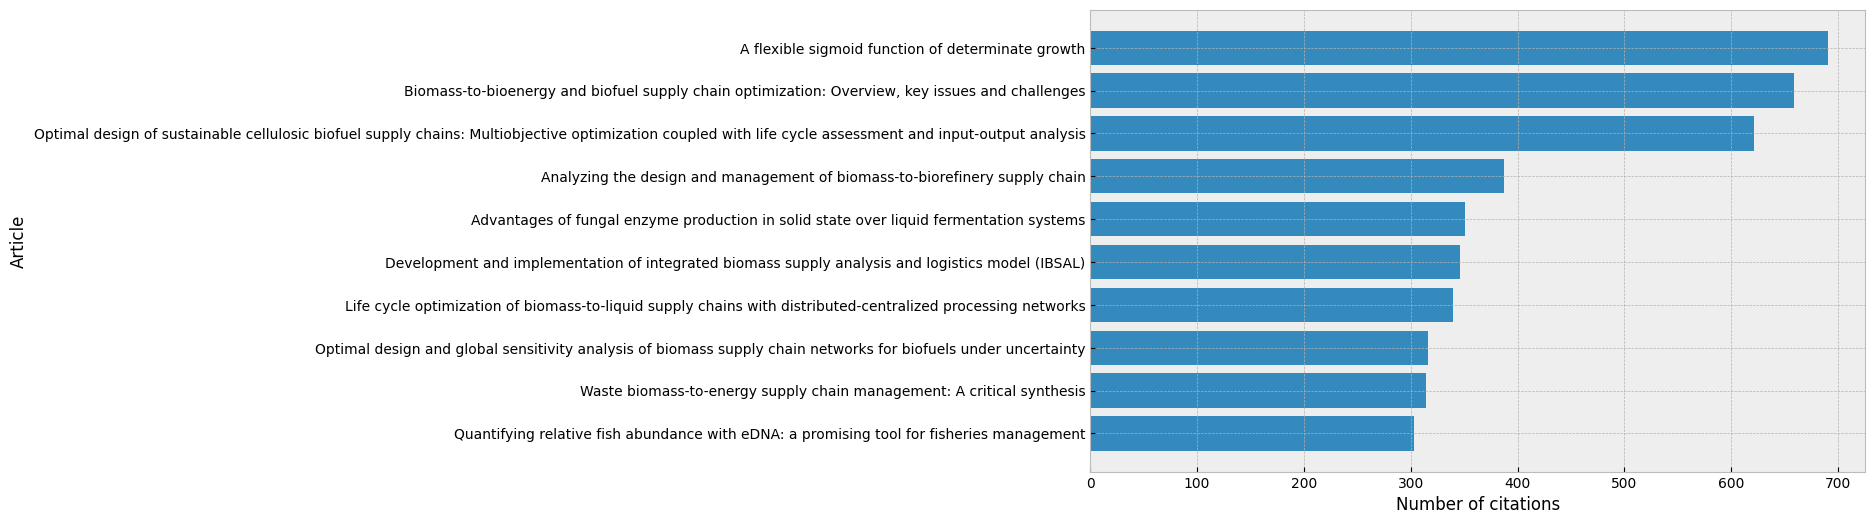

In [30]:
with open("/content/scopus31031912.bib", encoding="utf-8") as bibtex_file:
    bib_database = bibtexparser.load(bibtex_file)

titulos = []
citas = []

for entry in bib_database.entries:
    titulos.append(entry.get("title", "Sin título"))
    note_field = entry.get("note", "")
    match = re.search(r"Cited by:\s*(\d+)", note_field)
    citas.append(int(match.group(1)) if match else 0)

df_citas = pd.DataFrame({
    "Título": titulos,
    "Citas": citas
})

df_citas = df_citas.sort_values(by="Citas", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(df_citas["Título"].head(10), df_citas["Citas"].head(10))
plt.xlabel("Number of citations")
plt.ylabel("Article")
#plt.title("Top 10 artículos más citados")
plt.gca().invert_yaxis()
plt.show()


# **Análisis de redes de conocimiento**

In [31]:
# Network - Collaboration Analysis Between Countries using a Map. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            connections = True or False (True -> Countries connections will be displayed, False -> Countries connections will not be displayed);
#            country_lst = Highlight the Connections Between a List of Countries
bibfile.network_adj_map(view = 'notebook', connections = True, country_lst = ["colombia"])

/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.



In [32]:
# Network - Collaboration Analysis Between Authors, Countries, Intitutions Or Adjacency Analysis Between Authors' Keywords or Keywords Plus. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            adj_type    = 'aut', 'cout', 'inst', 'kwa', or 'kwp'
#            min_count   = Relationship between nodes that have connected at least x times;
#            node_labels = True or False (True -> The label IDs will be displayed, False -> Only the nodes will be displayed );
#            node_size   = -1. (If node_size = -1 then the default value will be used. If node_size > 0 then this new value will be used);
#            label_type  = 'id', 'name' (Only meaningfull if node_labels = True. 'id' -> The ID will be displayed; 'name' -> The name will be displayed);
#            centrality  = 'degree', 'load', 'betw', 'close', 'eigen', 'katz', 'harmonic', or None. Color nodes according to centrality criterion
#                          'degree'   = Degree Centrality
#                          'load'     = Load Centrality
#                          'betw'     = Betweenness Centrality
#                          'close'    = Closeness Centrality
#                          'eigen'    = Eigenvector Centrality
#                          'katz'     = Katz Centrality
#                          'harmonic' = Harmonic Centrality
#                           None      = The Community Algorithm, Girvan-Newman, will be used Instead of a Centrality Criterion
bibfile.network_adj(view = 'notebook', adj_type = 'kwa', min_count = 100, node_labels = True, label_type = 'name', centrality = 'eigen')

# PS: If a centrality criterion is used then the values can be obtained by the following command:  bibfile.table_centr

/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.



In [33]:
# Genera la tabla de valores
tabla_centralidad = bibfile.table_centr
print(tabla_centralidad.head(50))

                            Name  Node  Eigenvector
0                        biomass   k_0     0.250309
1                   optimization   k_1     0.248182
3                      bioenergy   k_3     0.240392
6                        biofuel   k_6     0.224163
2                   supply chain   k_2     0.219459
4                 sustainability   k_4     0.215478
10                      biofuels  k_10     0.209079
9                    biorefinery   k_9     0.208008
7                      logistics   k_7     0.206732
12                    simulation  k_12     0.188561
16       supply chain management  k_16     0.187755
31                          milp  k_31     0.181041
13              renewable energy  k_13     0.180846
11                   uncertainty  k_11     0.180235
8          life cycle assessment   k_8     0.173368
19                    bioethanol  k_19     0.172341
5           biomass supply chain   k_5     0.170904
14                           gis  k_14     0.169336
20          

In [34]:
# Network - Collaboration Analysis Between Authors, Countries, Intitutions Or Adjacency Analysis Between Authors' Keywords or Keywords Plus. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            adj_type    = 'aut', 'cout', 'inst', 'kwa', or 'kwp'
#            min_count   = Relationship between nodes that have connected at least x times;
#            node_labels = True or False (True -> The label IDs will be displayed, False -> Only the nodes will be displayed );
#            node_size   = -1. (If node_size = -1 then the default value will be used. If node_size > 0 then this new value will be used);
#            label_type  = 'id', 'name' (Only meaningfull if node_labels = True. 'id' -> The ID will be displayed; 'name' -> The name will be displayed);
#            centrality  = 'degree', 'load', 'betw', 'close', 'eigen', 'katz', 'harmonic', or None. Color nodes according to centrality criterion
#                          'degree'   = Degree Centrality
#                          'load'     = Load Centrality
#                          'betw'     = Betweenness Centrality
#                          'close'    = Closeness Centrality
#                          'eigen'    = Eigenvector Centrality
#                          'katz'     = Katz Centrality
#                          'harmonic' = Harmonic Centrality
#                           None      = The Community Algorithm, Girvan-Newman, will be used Instead of a Centrality Criterion
bibfile.network_adj(view = 'notebook', adj_type = 'kwa', min_count = 50, node_labels = True, label_type = 'name', centrality = 'betw')

# PS: If a centrality criterion is used then the values can be obtained by the following command:  bibfile.table_centr

/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.



In [35]:
tabla_betweenness = bibfile.table_centr

# 3. Visualizar los 30 términos con mayor poder de intermediación
print("Top 30 Nodos por Betweenness Centrality (Puentes del conocimiento):")
print(tabla_betweenness.sort_values(by='Betweenness', ascending=False).head(50))

Top 30 Nodos por Betweenness Centrality (Puentes del conocimiento):
                                Name  Node  Betweenness
1                       optimization   k_1     0.102416
0                            biomass   k_0     0.094654
2                       supply chain   k_2     0.053165
3                          bioenergy   k_3     0.045383
6                            biofuel   k_6     0.031844
7                          logistics   k_7     0.030569
5               biomass supply chain   k_5     0.026465
4                     sustainability   k_4     0.025097
10                          biofuels  k_10     0.022557
16           supply chain management  k_16     0.020685
9                        biorefinery   k_9     0.017339
8              life cycle assessment   k_8     0.016829
14                               gis  k_14     0.013536
13                  renewable energy  k_13     0.013305
15         supply chain optimization  k_15     0.012128
11                       uncertainty

# *Colaboración entre autores*

In [37]:
# Network - Collaboration Analysis Between Authors, Countries, Intitutions Or Adjacency Analysis Between Authors' Keywords or Keywords Plus. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            adj_type    = 'aut', 'cout', 'inst', 'kwa', or 'kwp'
#            min_count   = Relationship between nodes that have connected at least x times;
#            node_labels = True or False (True -> The label IDs will be displayed, False -> Only the nodes will be displayed );
#            node_size   = -1. (If node_size = -1 then the default value will be used. If node_size > 0 then this new value will be used);
#            label_type  = 'id', 'name' (Only meaningfull if node_labels = True. 'id' -> The ID will be displayed; 'name' -> The name will be displayed);
#            centrality  = 'degree', 'load', 'betw', 'close', 'eigen', 'katz', 'harmonic', or None. Color nodes according to centrality criterion
#                          'degree'   = Degree Centrality
#                          'load'     = Load Centrality
#                          'betw'     = Betweenness Centrality
#                          'close'    = Closeness Centrality
#                          'eigen'    = Eigenvector Centrality
#                          'katz'     = Katz Centrality
#                          'harmonic' = Harmonic Centrality
#                           None      = The Community Algorithm, Girvan-Newman, will be used Instead of a Centrality Criterion
bibfile.network_adj(view = 'notebook', adj_type = 'aut', min_count = 25, node_labels = True, label_type = 'name', centrality = 'eigen')

# PS: If a centrality criterion is used then the values can be obtained by the following command:  bibfile.table_centr

# **Preparando clustering de los documentos**

In [38]:
# Lectura de datasets y del modelo pre-entrenado
from datasets import load_dataset # 4.0.0
from sentence_transformers import SentenceTransformer # 5.2.0
from safetensors.numpy import save_file, load_file # 0.7.0. Opcional para guardar y recargar embeddings obtenidos

# Reducción de dimensionalidad y clustering
from umap import UMAP # 0.5.9.post2
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_score

# Exploración y visualización de datos
import random
import itertools

# Fijar semillas de generadores aleatorios
import torch
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [39]:
from datasets import Dataset

# Configuración de ruta
RUTA_BIB = '/content/scopus31031912.bib'
RUTA_PARQUET = '/content/dataset_scopus.parquet'

# Paso 1: Leer el archivo .bib
with open(RUTA_BIB, encoding='utf-8') as bibtex_file:
    bib_database = bibtexparser.load(bibtex_file)

# Paso 2: Convertir a DataFrame de Pandas
df = pd.DataFrame(bib_database.entries)

# Paso 3: Guardar como Parquet (Opcional, pero recomendado para persistencia)
df.to_parquet(RUTA_PARQUET)

# Paso 4: Cargar como un objeto Dataset de Hugging Face
# Ahora sí usamos el cargador de parquet porque el archivo ya tiene ese formato
dataset_tr = Dataset.from_pandas(df)

# Verificar el resultado
print(dataset_tr)
print(dataset_tr[0])

Dataset({
    features: ['note', 'source', 'publication_stage', 'type', 'abbrev_source_title', 'language', 'issn', 'publisher', 'correspondence_address', 'keywords', 'author_keywords', 'abstract', 'affiliations', 'url', 'doi', 'pages', 'volume', 'journal', 'year', 'title', 'author', 'ENTRYTYPE', 'ID', 'coden', 'number', 'pmid', 'isbn', 'editor'],
    num_rows: 1823
})
{'note': 'Cited by: 0', 'source': 'Scopus', 'publication_stage': 'Final', 'type': 'Article', 'abbrev_source_title': 'Sustainable Energy Technol. Assess.', 'language': 'English', 'issn': '22131388', 'publisher': 'Elsevier Ltd', 'correspondence_address': 'L. Wan; School of Economics and Management, Henan University of Urban Construction, Pingdingshan, Henan, 467036, China; email: 20141035@huuc.edu.cn', 'keywords': "Iowa; United States; Benchmarking; Biomass; Cellulosic ethanol; Cost benefit analysis; Economic analysis; Feedstocks; Gasification; Integer programming; Investments; Logistics; Profitability; Risk perception; Sal

In [41]:
resumenes = dataset_tr['abstract']
titulos = dataset_tr['title']
años = dataset_tr['year']

In [42]:
# Extraer un índice aleatorio
N = len(resumenes)
idx = random.randint(0, N)

# Extraer texto y darle formato
texto = resumenes[idx]
texto = textwrap.fill(texto, 100)

# Imprimir título y resumen
print(f"Título: {titulos[idx]}")
print('-'*25)
print(f"Resumen: {texto}")

Título: Newly developed water productivity and harvest index models for maize in an arid region
-------------------------
Resumen:                              Simulating yield response to different irrigation scenarios is
important for agricultural production, especially in the arid region where agriculture depends
heavily on irrigation. To better predict yield under different irrigation scenarios, the variation
of normalized water productivity (WP                             <sup>*</sup>
) over the whole growing period of maize for seed production and the effect of different irrigation
treatments on harvest index (HI) were investigated using field experiments from 2012 to 2015 in an
arid region of northwest China. Two new non-linear dynamic WP
<sup>*</sup>                              (WP                             <sup>*</sup>
<sub>KR-L</sub>                              and WP                             <sup>*</sup>
<sub>KR-S</sub>                             ) models derived fro

In [43]:
# Reemplaza los valores nulos (NaN) por una cadena vacía
df['abstract'] = df['abstract'].fillna('')
df['year'] = df['year'].fillna('')

# Luego extraes la lista nuevamente
resumenes = df['abstract'].tolist()

# Ahora tu código original funcionará sin errores
sizes = [len(text.split()) for text in resumenes]

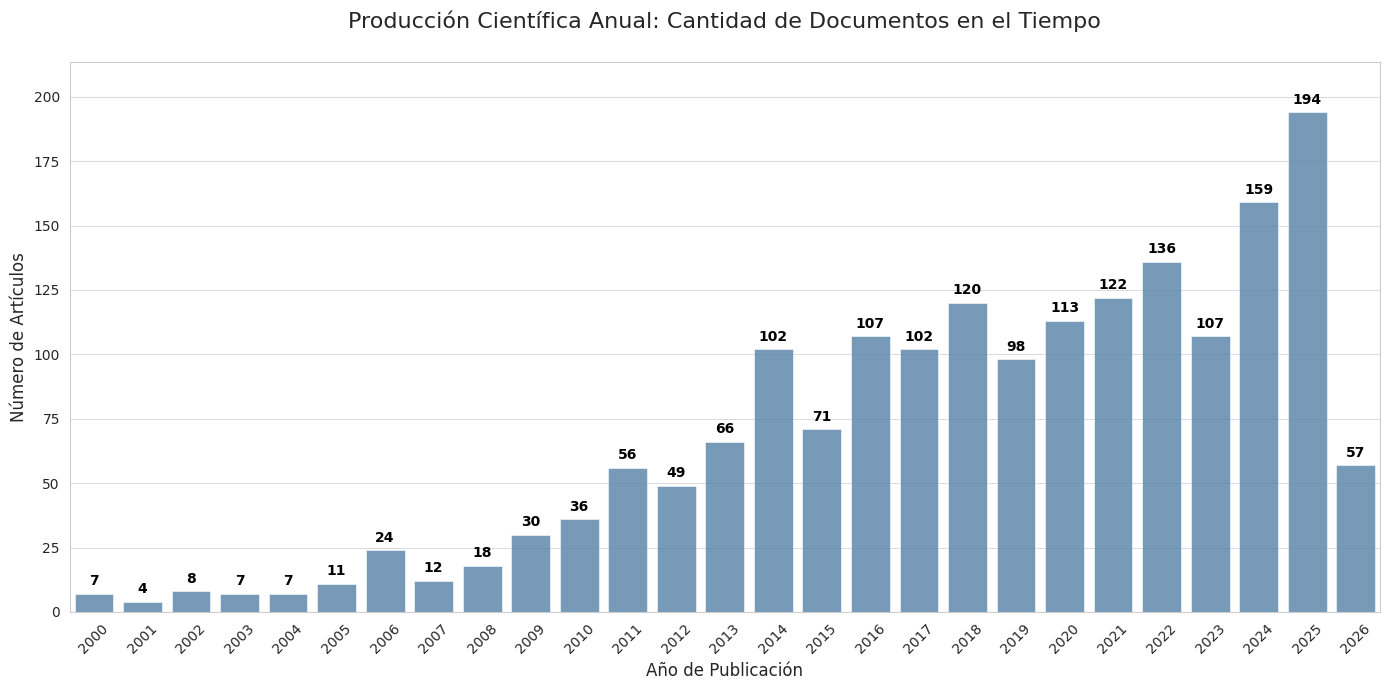

In [46]:
# 1. Asegurar limpieza y conversión (Mantenemos la lógica anterior)
df['year_clean'] = pd.to_numeric(df['year'], errors='coerce')
df_plot = df.dropna(subset=['year_clean'])
df_plot = df_plot[(df_plot['year_clean'] > 1990) & (df_plot['year_clean'] <= 2026)]
df_plot['year_clean'] = df_plot['year_clean'].astype(int)

# 2. Contar documentos por año
conteo_anual = df_plot.groupby('year_clean').size().reset_index(name='Cantidad')

# 3. Crear la gráfica
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Dibujar las barras
barras = sns.barplot(data=conteo_anual, x='year_clean', y='Cantidad', color='steelblue', alpha=0.8)

# --- NUEVO: Añadir etiquetas a cada barra ---
for p in barras.patches:
    barras.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=10,
                   fontweight='bold',
                   color='black')

# 4. Estética
plt.title('Producción Científica Anual: Cantidad de Documentos en el Tiempo', fontsize=16, pad=25)
plt.xlabel('Año de Publicación', fontsize=12)
plt.ylabel('Número de Artículos', fontsize=12)
plt.xticks(rotation=45)

# Ajustar el límite superior del eje Y para que las etiquetas no se corten
plt.ylim(0, conteo_anual['Cantidad'].max() * 1.1)

plt.tight_layout()
plt.show()

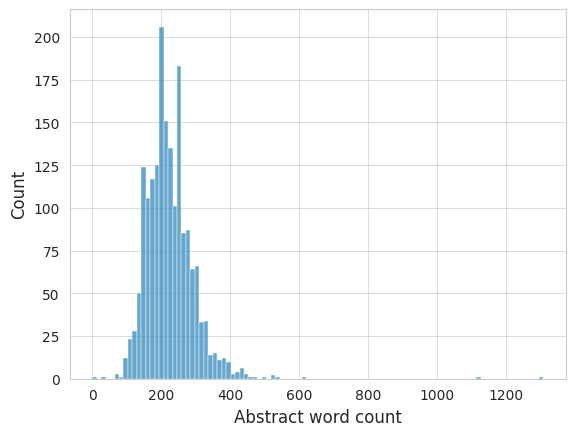

In [47]:
# Tamaños de los textos
sizes = []
for text in resumenes:
    words = text.split()
    sizes.append(len(words))

# Histograma
sns.histplot(sizes)
plt.xlabel("Abstract word count");

In [48]:
#RUTA_MODELO = 'google/embeddinggemma-300m'  # Modelo alternativo
#RUTA_MODELO = 'sentence-transformers/sentence-t5-base'
#RUTA_MODELO = "mixedbread-ai/mxbai-embed-large-v1"
RUTA_MODELO = "intfloat/e5-large-v2"
embedding_model = SentenceTransformer(RUTA_MODELO)

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/314 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

In [49]:
embedding_model

SentenceTransformer(
  (0): Transformer({'max_seq_length': 512, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 1024, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)

In [50]:
embeddings = embedding_model.encode(resumenes, show_progress_bar=True)

Batches:   0%|          | 0/57 [00:00<?, ?it/s]

In [51]:
print("Ejemplo de un 'embedding':")
print(embeddings[10])
print("-"*20)
print(f"Tamaño de los embeddings: {embeddings.shape}")

Ejemplo de un 'embedding':
[-0.00396219 -0.07271075 -0.01315528 ... -0.03946905  0.04108907
 -0.00055777]
--------------------
Tamaño de los embeddings: (1823, 1024)


In [52]:
# Guardar con "safetensors"
save_file({"embeddings": embeddings}, "embs_resumenes_esp_tr1.safetensors")

# **Reducción de la dimensionalidad**

In [53]:
umap_model = UMAP(
    n_components=5, # Nueva dimensionalidad (comprimir de 1024 a 5)
    min_dist=0.0, # Si dos resúmenes son muy similares codificarlos prácticamente de la misma forma
    metric='cosine', # Usar similitud del coseno para cuantificar distancia entre "embeddings"
    random_state=42, # Fijar semilla para reproducibilidad de los resultados
    n_jobs = 1 # Para reproducibilidad de los resultados
)
embeddings_reducidos = umap_model.fit_transform(embeddings)

En este punto tendremos la misma cantidad de embeddings original, pero ahora en lugar de usar vectores de 1028 elementos para representarlos usaremos vectores de 5 elementos

In [54]:
embeddings_reducidos.shape

(1823, 5)

# **Aplicación del clustering de texto**

Implementamos el método HDBSCAN definiendo dos hiper-parámetros:

"min_samples": cuántos puntos vecinos de otro punto se consideran para determinar si dicho punto es "core". Entre más grande sea "min_samples" más puntos etiquetados como ruido (-1) tendremos
"min_cluster_size": el número mínimo de datos para considerar que tenemos un "cluster"
Y lo que nos interesa es encontrar una combinación adecuada de hiper-parámetros que retorne un puntaje silueta adecuado y que a la vez no genere un número elevado de "outliers".

Así que seguiremos este procedimiento:

a) Definiremos un rango de valores para "min_samples" y para "min_cluster_size"
b) Por cada combinación de valores de estos dos hiper-parámetros:
    -Construiremos un modelo HDBSCAN
    -Calcularemos y almacenaremos el puntaje silueta, el porcentaje de "outliers" y el número de agrupaciones generadas
c) Al final buscaremos una combinación de hiper-parámetros donde el puntaje silueta resulte adecuado (mayor que 0.5), el porcentaje de "outliers" no sea tan elevado y el número de clusters no resulte ni excesivamente pequeño ni excesivamente grande.

In [55]:
# Combinatoria de MS y MCS
MS = range(2, 31, 4) # 2, , 6, ... 30
MCS = range(2, 31, 4) # 2,  6,... 30

# Todos los posibles pares de combinaciones
pares = list(itertools.product(MS, MCS))
npares = len(pares)

resultados = []
for i, par in enumerate(pares):
    print(f"Probando combinación {i+1}/{npares} ({par})...")
    ms, mcs = par[0], par[1]
    hdb = HDBSCAN(min_samples=ms, min_cluster_size=mcs).fit(embeddings_reducidos)
    labels = hdb.labels_

    # Calcular porcentaje de ruido
    pctj_ruido = np.sum(labels == -1) / len(labels)

    # Calcular puntaje silueta sólo en datos que no sean ruido
    idx = labels != -1
    if np.sum(idx) > 0:
        n_clusters = len(set(labels[idx]))
        if n_clusters > 1:
            score = silhouette_score(embeddings_reducidos[idx], labels[idx])
            resultados.append({'min_samples': ms, 'min_cluster_size': mcs,
                               'silueta': score, 'ruido': pctj_ruido, 'n_clusters': n_clusters})

# Crear dataframe de resultados y ordenar por puntaje silueta
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('silueta', ascending=False)

Probando combinación 1/64 ((2, 2))...
Probando combinación 2/64 ((2, 6))...
Probando combinación 3/64 ((2, 10))...
Probando combinación 4/64 ((2, 14))...
Probando combinación 5/64 ((2, 18))...
Probando combinación 6/64 ((2, 22))...
Probando combinación 7/64 ((2, 26))...
Probando combinación 8/64 ((2, 30))...
Probando combinación 9/64 ((6, 2))...
Probando combinación 10/64 ((6, 6))...
Probando combinación 11/64 ((6, 10))...
Probando combinación 12/64 ((6, 14))...
Probando combinación 13/64 ((6, 18))...
Probando combinación 14/64 ((6, 22))...
Probando combinación 15/64 ((6, 26))...
Probando combinación 16/64 ((6, 30))...
Probando combinación 17/64 ((10, 2))...
Probando combinación 18/64 ((10, 6))...
Probando combinación 19/64 ((10, 10))...
Probando combinación 20/64 ((10, 14))...
Probando combinación 21/64 ((10, 18))...
Probando combinación 22/64 ((10, 22))...
Probando combinación 23/64 ((10, 26))...
Probando combinación 24/64 ((10, 30))...
Probando combinación 25/64 ((14, 2))...
Proband

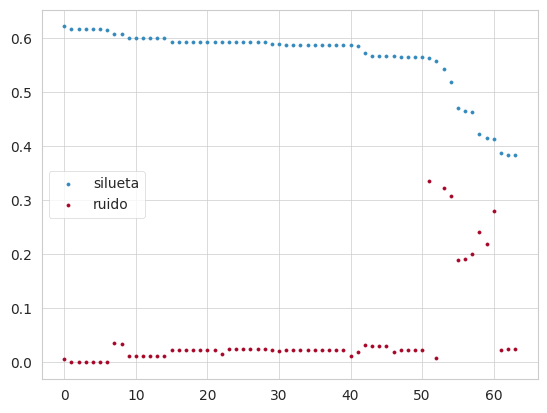

In [56]:
plt.scatter(range(len(df_resultados)),df_resultados['silueta'],s=5, label='silueta')
plt.scatter(range(len(df_resultados)),df_resultados['ruido'],s=5, label='ruido')
plt.legend();

In [57]:
df_resultados.head(50)

,min_samples,min_cluster_size,silueta,ruido,n_clusters
63,30,30,0.621582,0.007131,3
15,6,30,0.617146,0.001097,3
23,10,30,0.617146,0.001097,3
14,6,26,0.617146,0.001097,3
31,14,30,0.617146,0.001097,3
22,10,26,0.617146,0.001097,3
7,2,30,0.615413,0.000000,3
55,26,30,0.607991,0.036204,4
47,22,30,0.607749,0.035107,4
57,30,6,0.599599,0.012068,4


In [58]:
hdbscan = HDBSCAN(min_samples=18, min_cluster_size=10)
clusters = hdbscan.fit_predict(embeddings_reducidos)
clusters

array([0, 0, 0, ..., 0, 1, 1])

In [59]:
len(set(clusters))

8

In [60]:
# Porcentaje de outliers
pctj_outliers = np.sum(clusters == -1) / len(clusters)
print(f"Porcentaje de outliers: {100*pctj_outliers:.1f} %")

Porcentaje de outliers: 2.3 %


*Exploración de los "clusters" generados*

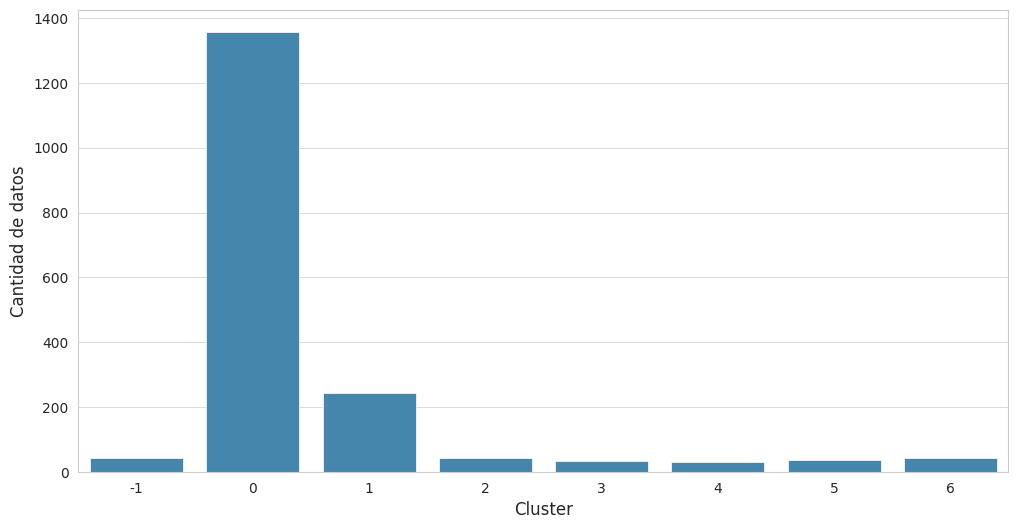

In [61]:
# Distribución de las agrupaciones
fig, ax = plt.subplots(figsize=(12,6))
df_clusters = pd.Series(clusters).value_counts()
sns.barplot(x=df_clusters.index, y=df_clusters.values)
ax.set_xlabel('Cluster')
ax.set_ylabel('Cantidad de datos');

In [62]:
# Exploración
# label = -1 # outliers
label = -1

idxs = np.where(clusters==label)[0]

for i in range(5):
    idx = np.random.choice(idxs).item()
    resumen = resumenes[idx]
    resumen = textwrap.fill(resumen, width=100)
    print(f"--- Documento {idx} ---")
    print(resumen)
    print("\n")

--- Documento 1726 ---
Large quantity of residual biomass with possible energy and industrial end can be obtained from
management operations of urban forests. The profitability of exploiting these resources is
conditioned by the amount of existing biomass within urban community ecosystems. This research was
focused on direct and indirect quantification of lignocellulosic waste from urban tree pruning of
Morus alba, which is widely deployed as ornamental vegetation in Mediterranean countries. The mean
quantity of dried pruned biomass obtained in street and park location was 31.67kg/tree and
77.78kg/tree with standard deviation 16.88kg/tree and 29.51kg/tree, respectively. Mathematical
models for predicting the available amount of pruning residues for this species were developed from
easily measurable dendrometric parameters, such as diameter at breast height, crown diameter and
total tree height. The best functions were obtained when several variables were combined in
quadratics models. 

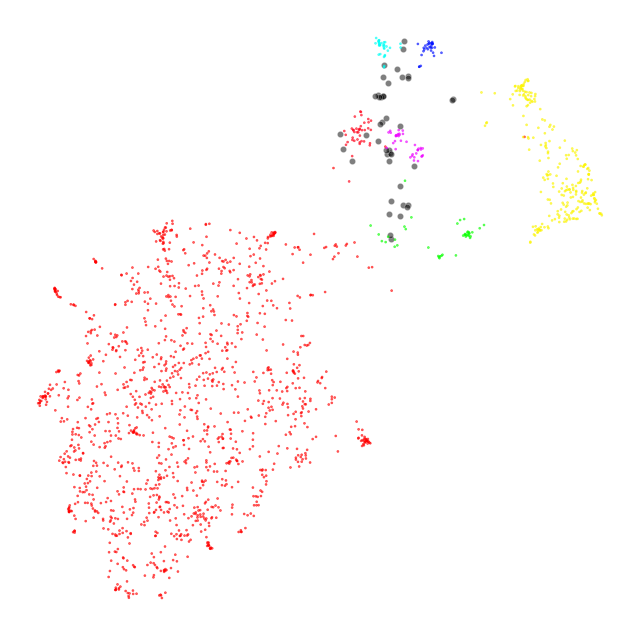

In [63]:
# Exploración como gráficos 2d
embeddings_2D = UMAP(
    n_components = 2,
    min_dist = 0.0,
    metric = "cosine",
    random_state = 42,
    n_jobs = 1
).fit_transform(embeddings)

# Crear un DataFrame con la información 2D
df = pd.DataFrame(embeddings_2D, columns=["x", "y"])
df["titulo"] = titulos
df["cluster"] = [str(c) for c in clusters]

# Crear dataframes de clusters y de outliers
clusters_df = df.loc[df.cluster != "-1", :]
outliers_df = df.loc[df.cluster == "-1", :]

# Y hacer gráficos de dispersión
fig, ax = plt.subplots(figsize=(8,8))
sns.scatterplot(outliers_df, x="x", y="y", alpha=0.5, s=20,
            c="black")
plt.scatter(clusters_df.x, clusters_df.y,
            c=clusters_df.cluster.astype(int),
            alpha=0.6, s=2, cmap="hsv")
plt.axis("off");

In [64]:
clusters_df

,x,y,titulo,cluster
0,-1.755479,-3.600823,Comprehensive techno economic and logistic ass...,0
1,-3.455142,-1.712648,Forest 4.0: Technologies and digitalization to...,0
2,-3.800905,-4.651969,A systematic evaluation of risk in bioenergy s...,0
3,-3.768846,-2.898467,Integrating Biotechnological Innovations for G...,0
4,-1.438699,-3.401074,Large-scale spatially explicit analysis of car...,0
...,...,...,...,...
1817,-1.984849,-1.460829,Process simulation of rice straw torrefaction,0
1818,3.906013,-0.074676,High production of hyaluronic and lactic acids...,1
1820,-0.795367,-2.495091,Forest biomass supply logistics for a power pl...,0
1821,4.036583,-0.515132,Fundamental Escherichia coli Biochemical Pathw...,1


In [65]:
!pip install bertopic==0.17.4 nltk==3.9.1 langdetect==1.0.9

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 11.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=0b844f5478f1f413b5ea3edc74d55f3d5c86f418d7df0274e2b7a84f62a599fd
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [66]:
# Reducción de dimensionalidad, clustering y modelado de tópicos
from umap import UMAP # 0.5.9.post2
from sklearn.cluster import HDBSCAN
from bertopic import BERTopic

# Procesamiento adicional del texto
from langdetect import detect
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

# **Uso de Bertopic**

In [67]:
# Crear instancia de BERTopic especificando únicamente el método de clustering
topic_model = BERTopic(
    # embedding_model=embedding_model,
    top_n_words = 10, # el número de palabras clave a extraer por cada tópico (10 por defecto)
    umap_model=umap_model,
    hdbscan_model=hdbscan,
    verbose=True)
topic_model.fit(resumenes)

2026-04-05 22:46:48,949 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/57 [00:00<?, ?it/s]

2026-04-05 22:49:51,159 - BERTopic - Embedding - Completed ✓
2026-04-05 22:49:51,160 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-05 22:49:56,444 - BERTopic - Dimensionality - Completed ✓
2026-04-05 22:49:56,446 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-05 22:49:56,486 - BERTopic - Cluster - Completed ✓
2026-04-05 22:49:56,491 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-05 22:49:56,824 - BERTopic - Representation - Completed ✓


In [71]:
loaded = load_file("/content/embs_resumenes_esp_tr1.safetensors")
embeddings = loaded["embeddings"]

*Exploración de topicos*

In [72]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,770,-1_the_of_and_to,"[the, of, and, to, in, for, biomass, is, suppl...",[Biorefineries appear to be a viable solution ...
1,0,154,0_growth_the_fermentation_was,"[growth, the, fermentation, was, and, of, prod...",[Lactic acid has a wide industrial application...
2,1,128,1_the_and_to_of,"[the, and, to, of, biomass, for, in, is, suppl...",[Second generation biofuels offer the opportun...
3,2,111,2_the_of_forest_and,"[the, of, forest, and, wood, to, in, for, from...",[Wood fuel quality attributes have to be consi...
4,3,98,3_the_supply_to_and,"[the, supply, to, and, model, stochastic, of, ...","[Recently, the biomass has gained considerable..."
5,4,78,4_growth_the_of_and,"[growth, the, of, and, was, in, microalgae, co...",[A mathematical modeling of microalgae biomass...
6,5,51,5_the_and_of_to,"[the, and, of, to, is, supply, environmental, ...",[Biofuels production has been promoted in the ...
7,6,46,6_and_the_to_of,"[and, the, to, of, social, in, bioenergy, sust...",[Bioenergy is a building block of the ongoing ...
8,7,43,7_biodiesel_the_supply_of,"[biodiesel, the, supply, of, is, chain, and, t...",[The need for sustainable energy generation ha...
9,8,36,8_forest_and_the_in,"[forest, and, the, in, of, models, with, to, a...",[Aim. Our aims were to quantify climatic and s...


*Mejorando los topicos obtenidos*

In [73]:
# Descargar listado de stop words en ingles
nltk.download('stopwords')
stop_words1 = stopwords.words('english')
stop_wordsex = []
stop_words = list(set(stop_words1 + stop_wordsex))
print(f"Total de palabras en la lista: {len(stop_words)}")
print(stop_words)

Total de palabras en la lista: 198
['wasn', 'again', 'be', 'further', 'your', 'into', 'my', "you'll", 'had', 'o', "don't", "you'd", 'yourselves', 'an', "doesn't", 'out', 'each', 'those', 'this', 'from', 'own', 'myself', 'at', 'won', 'nor', 'more', "couldn't", 'its', 'am', 'ours', "weren't", 'him', 'not', "isn't", 'than', 'then', 'couldn', "we'd", 'because', 'down', 'yours', 'having', 'both', 'll', 'were', 'how', 'been', 'against', 'theirs', 'herself', 'don', 'by', 'being', "they'll", 'whom', 'can', 'her', 'himself', "needn't", 'or', "he'd", "you're", 'on', "they'd", 'so', 'other', "i'll", "it'd", 'in', 'over', "it'll", 'which', 'if', 'and', 'didn', 'until', "that'll", 'off', "they've", 'should', 'aren', 'just', 'is', 'will', 'while', 'same', 'once', "i've", 'we', 'needn', "we'll", 'but', 'itself', 'me', 'these', 'hadn', 'to', 'weren', 'his', 'of', 'about', 'now', "he'll", 'they', 'she', 'it', 'he', "aren't", 'i', 'y', 'hasn', 'ain', 'm', "mightn't", 'mustn', 'that', 'above', 'before', 

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [74]:
vectorizer_model = CountVectorizer(
    stop_words=stop_words,
    strip_accents=None)

In [75]:
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan,
    language = "english",
    vectorizer_model=vectorizer_model, ### Clave: NO CAMBIAR EMBEDDINGS, EN LOS EMBEDDINGS SÍ SE USAN LOS STOP WORDS
verbose=True)

topic_model.fit(resumenes, np.array(embeddings)); # <--- clave: usar los embeddings de textos sólo en ingles

2026-04-05 23:03:54,967 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-05 23:04:09,888 - BERTopic - Dimensionality - Completed ✓
2026-04-05 23:04:09,891 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-05 23:04:09,978 - BERTopic - Cluster - Completed ✓
2026-04-05 23:04:09,992 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-05 23:04:11,289 - BERTopic - Representation - Completed ✓


In [76]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,42,-1_yield_soil_survival_biomass,"[yield, soil, survival, biomass, growth, model...",[Belowground processes and associated plant-mi...
1,0,1358,0_supply_biomass_chain_energy,"[supply, biomass, chain, energy, model, produc...",[Within a large set of renewable energies bein...
2,1,242,1_growth_production_model_fermentation,"[growth, production, model, fermentation, conc...",[Monod and Logistic growth models have been wi...
3,2,41,2_methane_logistic_model_biogas,"[methane, logistic, model, biogas, production,...",[Anaerobic Digestion represents an economicall...
4,3,41,3_forest_models_tree_biomass,"[forest, models, tree, biomass, stand, agb, mo...",[This paper aims to assess the performance of ...
5,4,37,4_growth_yield_irrigation_lai,"[growth, yield, irrigation, lai, weed, biomass...",[The Leaf Area Index (LAI) strongly influences...
6,5,32,5_population_density_model_assumed,"[population, density, model, assumed, growth, ...",[A nonlinear mathematical model to study the e...
7,6,30,6_data_estimates_fishing_model,"[data, estimates, fishing, model, fish, biomas...",[Control of long-established invasive species ...


In [77]:
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan,
    language = "english",
    vectorizer_model=vectorizer_model, ### Clave: NO CAMBIAR EMBEDDINGS, EN LOS EMBEDDINGS SÍ SE USAN LOS STOP WORDS
    nr_topics = "auto", # Aplica nuevamente HDBSCAN pero sobre c-TF-IDF para reducir el número de tópicos
    verbose=True)
topic_model.fit_transform(resumenes, np.array(embeddings));

2026-04-05 23:04:24,182 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-05 23:04:33,737 - BERTopic - Dimensionality - Completed ✓
2026-04-05 23:04:33,739 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-05 23:04:33,776 - BERTopic - Cluster - Completed ✓
2026-04-05 23:04:33,777 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-05 23:04:34,144 - BERTopic - Representation - Completed ✓
2026-04-05 23:04:34,145 - BERTopic - Topic reduction - Reducing number of topics
2026-04-05 23:04:34,190 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-05 23:04:34,539 - BERTopic - Representation - Completed ✓
2026-04-05 23:04:34,542 - BERTopic - Topic reduction - Reduced number of topics from 8 to 8


In [78]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,42,-1_yield_soil_survival_biomass,"[yield, soil, survival, biomass, growth, model...",[Belowground processes and associated plant-mi...
1,0,1358,0_supply_biomass_chain_energy,"[supply, biomass, chain, energy, model, produc...",[Within a large set of renewable energies bein...
2,1,242,1_growth_production_model_fermentation,"[growth, production, model, fermentation, conc...",[Monod and Logistic growth models have been wi...
3,2,41,2_methane_logistic_model_biogas,"[methane, logistic, model, biogas, production,...",[Anaerobic Digestion represents an economicall...
4,3,41,3_forest_models_tree_biomass,"[forest, models, tree, biomass, stand, agb, mo...",[This paper aims to assess the performance of ...
5,4,37,4_growth_yield_irrigation_lai,"[growth, yield, irrigation, lai, weed, biomass...",[The Leaf Area Index (LAI) strongly influences...
6,5,32,5_population_density_model_assumed,"[population, density, model, assumed, growth, ...",[A nonlinear mathematical model to study the e...
7,6,30,6_data_estimates_fishing_model,"[data, estimates, fishing, model, fish, biomas...",[Control of long-established invasive species ...


# **Exploración de topicos**

In [79]:
# Cada valor es el c-TF-IDF normalizado
topic_model.get_topic(6)

[('data', np.float64(0.05906969241995282)),
 ('estimates', np.float64(0.040252247586480536)),
 ('fishing', np.float64(0.03919745008029646)),
 ('model', np.float64(0.03489147843739106)),
 ('fish', np.float64(0.033411759548089844)),
 ('biomass', np.float64(0.033270654399083645)),
 ('msy', np.float64(0.032090123584135856)),
 ('population', np.float64(0.0314168375941416)),
 ('fishery', np.float64(0.030679324958358272)),
 ('fisheries', np.float64(0.029672755483910313))]

In [80]:
# Info a nivel de documento
topic_model.get_document_info(resumenes)

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,The commercial deployment of cellulosic biofue...,0,0_supply_biomass_chain_energy,"[supply, biomass, chain, energy, model, produc...",[Within a large set of renewable energies bein...,supply - biomass - chain - energy - model - pr...,1.000000,False
1,"Currently, there is an increasing pressure to ...",0,0_supply_biomass_chain_energy,"[supply, biomass, chain, energy, model, produc...",[Within a large set of renewable energies bein...,supply - biomass - chain - energy - model - pr...,1.000000,False
2,We introduce a novel method of evaluating risk...,0,0_supply_biomass_chain_energy,"[supply, biomass, chain, energy, model, produc...",[Within a large set of renewable energies bein...,supply - biomass - chain - energy - model - pr...,0.996281,False
3,This paper first examines the components of lo...,0,0_supply_biomass_chain_energy,"[supply, biomass, chain, energy, model, produc...",[Within a large set of renewable energies bein...,supply - biomass - chain - energy - model - pr...,1.000000,False
4,The large-scale production of cellulosic biofu...,0,0_supply_biomass_chain_energy,"[supply, biomass, chain, energy, model, produc...",[Within a large set of renewable energies bein...,supply - biomass - chain - energy - model - pr...,1.000000,False
...,...,...,...,...,...,...,...,...
1818,"The combined production of biomass, hyaluronic...",1,1_growth_production_model_fermentation,"[growth, production, model, fermentation, conc...",[Monod and Logistic growth models have been wi...,growth - production - model - fermentation - c...,1.000000,False
1819,Theory predicts that the effects of regional r...,-1,-1_yield_soil_survival_biomass,"[yield, soil, survival, biomass, growth, model...",[Belowground processes and associated plant-mi...,yield - soil - survival - biomass - growth - m...,0.000000,False
1820,This study investigates the logistics of suppl...,0,0_supply_biomass_chain_energy,"[supply, biomass, chain, energy, model, produc...",[Within a large set of renewable energies bein...,supply - biomass - chain - energy - model - pr...,1.000000,False
1821,Cells grow by oxidizing nutrients using a comp...,1,1_growth_production_model_fermentation,"[growth, production, model, fermentation, conc...",[Monod and Logistic growth models have been wi...,growth - production - model - fermentation - c...,0.610680,False


In [81]:
# Listado completo de tópicos
topic_model.get_topics()

{-1: [('yield', np.float64(0.029564534354329364)),
  ('soil', np.float64(0.027234969915420376)),
  ('survival', np.float64(0.02521337495838362)),
  ('biomass', np.float64(0.02330565282331472)),
  ('growth', np.float64(0.022939029447243693)),
  ('models', np.float64(0.022470206231755333)),
  ('data', np.float64(0.022057904910975926)),
  ('biochar', np.float64(0.020145970730069563)),
  ('species', np.float64(0.020143274834460108)),
  ('litter', np.float64(0.01972955489981177))],
 0: [('supply', np.float64(0.03873537361557838)),
  ('biomass', np.float64(0.03822142914301329)),
  ('chain', np.float64(0.029827894444856274)),
  ('energy', np.float64(0.027268471550126117)),
  ('model', np.float64(0.0257766194481737)),
  ('production', np.float64(0.02241865222196189)),
  ('study', np.float64(0.020364956317856668)),
  ('cost', np.float64(0.01982203320822863)),
  ('costs', np.float64(0.016291554163658427)),
  ('results', np.float64(0.015561586941277107))],
 1: [('growth', np.float64(0.05813208651

In [82]:
# Mostrar títulos de los documentos y
# tópicos a los que pertenecen
fig = topic_model.visualize_documents(
      list(titulos), # Formato lista
      embeddings=np.array(embeddings).astype(float), # Embeddings ÚNICAMENTE con textos en ingles
      width=1200,
      hide_annotations=True
  )

# Actualizar tamaño de fuentes para facilitar visualización
fig.update_layout(font=dict(size=16))

In [83]:
topic_model.visualize_topics()

In [84]:
topic_model.visualize_heatmap()

In [ ]:
topicos_a_combinar = [[0, 26, 21, 49], [3, 4, 8, 18, 31, 33], [15, 22, 44, 47], [7, 37], [12, 14], [13, 17]]
topic_model.merge_topics(resumenes, topicos_a_combinar)
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,691,-1_biomass_supply_chain_model,"[biomass, supply, chain, model, energy, cost, ...",[Many studies have developed mathematical prog...
1,0,273,0_growth_fermentation_production_logistic,"[growth, fermentation, production, logistic, c...",[Tertiary wastewater treatment by microalgae h...
2,1,154,1_forest_wood_biomass_supply,"[forest, wood, biomass, supply, costs, energy,...",[Many jurisdictions within the boreal and temp...
3,2,115,2_supply_chain_model_network,"[supply, chain, model, network, proposed, biom...","[Recently, the biomass has gained considerable..."
4,3,107,3_biodiesel_supply_energy_model,"[biodiesel, supply, energy, model, chain, envi...",[The ever-increasing energy demand and harmful...
5,4,42,4_energy_biogas_biomass_hemp,"[energy, biogas, biomass, hemp, pet, use, powe...","[Recently, to obtain biogas from biomass, an i..."
6,5,35,5_hydrogen_gasification_production_plant,"[hydrogen, gasification, production, plant, en...","[In this paper, a discrete event model is deve..."
7,6,34,6_carbon_beccs_power_emissions,"[carbon, beccs, power, emissions, ccs, use, el...",[The UK is the first major economy to legislat...
8,7,33,7_yield_irrigation_growth_weed,"[yield, irrigation, growth, weed, soil, lai, m...",[Plant height (PH) plays a crucial role in det...
9,8,31,8_energy_biomass_gas_renewable,"[energy, biomass, gas, renewable, bioenergy, p...",[Bioenergy technologies offer potential for re...


# **Mejorando los topicos con Re - ranking**

In [85]:
# Mejora de las representaciones
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance

# Procesamiento adicional del texto (para MMR)
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

Usar KeyBERT y MMR para mejorar los resultados del modelado de tópicos del set de datos usado

In [86]:
# UMAP
umap_model = UMAP(
    n_components=5, # Nueva dimensionalidad (comprimir de 768 a 5)
    min_dist=0.0, # Si dos resúmenes son muy similares codificarlos prácticamente de la misma forma
    metric='cosine', # Usar similitud del coseno para cuantificar distancia entre "embeddings"
    random_state=42, # Fijar semilla para reproducibilidad de los resultados
    n_jobs = 1 # Para reproducibilidad de los resultados
)

# Clustering (HDBSCAN)
hdbscan = HDBSCAN(min_samples=10, min_cluster_size=6)

# BERTopic
embeddings = np.array(embeddings) # Se debe presentar como arreglo de NumPy

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan,
    language = "english",
    nr_topics = "auto", # Aplica nuevamente HDBSCAN pero sobre c-TF-IDF para reducir el número de tópicos
    verbose=True)
topic_model.fit(resumenes, np.array(embeddings));

2026-04-05 23:06:49,785 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-05 23:06:57,554 - BERTopic - Dimensionality - Completed ✓
2026-04-05 23:06:57,555 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-05 23:06:57,600 - BERTopic - Cluster - Completed ✓
2026-04-05 23:06:57,602 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-05 23:06:58,199 - BERTopic - Representation - Completed ✓
2026-04-05 23:06:58,201 - BERTopic - Topic reduction - Reducing number of topics
2026-04-05 23:06:58,224 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-05 23:06:58,728 - BERTopic - Representation - Completed ✓
2026-04-05 23:06:58,731 - BERTopic - Topic reduction - Reduced number of topics from 10 to 6


In [87]:
# Extraer listado de tópicos originales
topicos_originales = topic_model.topic_representations_
topicos_originales

{-1: [('the', np.float64(0.0728527755035785)),
  ('and', np.float64(0.06895704135400224)),
  ('of', np.float64(0.06733210843898359)),
  ('in', np.float64(0.04401266396171334)),
  ('to', np.float64(0.04045489474048465)),
  ('for', np.float64(0.03304470595870193)),
  ('was', np.float64(0.0302323792281664)),
  ('with', np.float64(0.028334317412851716)),
  ('were', np.float64(0.025652745811461763)),
  ('we', np.float64(0.024066046063226036))],
 0: [('the', np.float64(0.08477264434981494)),
  ('of', np.float64(0.06542506861394003)),
  ('and', np.float64(0.06524630293368137)),
  ('to', np.float64(0.0514009102533018)),
  ('in', np.float64(0.04294930760970668)),
  ('for', np.float64(0.0354106617880656)),
  ('biomass', np.float64(0.031208578650650912)),
  ('is', np.float64(0.030978234665111334)),
  ('supply', np.float64(0.027365397600231517)),
  ('this', np.float64(0.023797478707303043))],
 1: [('the', np.float64(0.06744400048997527)),
  ('and', np.float64(0.06703593657874654)),
  ('of', np.flo

In [88]:
def diferencias_topicos(modelo, topicos_originales, n_terminos=10):

    df = pd.DataFrame(columns=['Tópico', 'Términos Originales', 'Términos Actualizados'])

    # OBTENEMOS LOS IDS REALES: Esto evita el KeyError
    # Solo recorre los números que el modelo REALMENTE tiene guardados
    ids_reales = modelo.get_topic_info()['Topic'].unique()

    for topico in ids_reales:
        if topico == -1: continue # Ignoramos los outliers (ruido)

        # 1. Extraer términos del modelo nuevo (KeyBERT/Large)
        # Usamos modelo.get_topic(topico) directamente
        actualizados = [t[0] for t in modelo.get_topic(topico)[:n_terminos]]
        term_actualizados = " | ".join(actualizados)

        # 2. Intentar buscar el equivalente en los originales
        # Si no existe (porque se borró en el "auto"), ponemos un aviso
        if topico in topicos_originales:
            originales = [t[0] for t in topicos_originales[topico][:n_terminos]]
            term_originales = " | ".join(originales)
        else:
            term_originales = "ID no presente en original (Reducción automática)"

        df.loc[len(df)] = [topico, term_originales, term_actualizados]

    return df

In [ ]:
def diferencias_topicos(modelo, topicos_originales, nr_topicos=5, n_terminos=10):
    df = pd.DataFrame(columns = ['Tópico', 'Original', 'Actualizado'])
    for topico in range(nr_topicos):
        # Extraer los top-nr_topicos términos por cada tópico
        term_originales  = " | ".join(list(zip(*topicos_originales[topico]))[0][:n_terminos])
        term_actualizados = " | ".join(list(zip(*modelo.get_topic(topico)))[0][:n_terminos])
        df.loc[len(df)] = [topico, term_originales, term_actualizados]
    return df

# **Aplicando KEYBERTinspired**

In [89]:
RUTA_MODELO = "intfloat/e5-large-v2"
embedding_model = SentenceTransformer(RUTA_MODELO)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/e5-large-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [90]:
# Instancia de KeyBERTInspired()
representation_model = KeyBERTInspired()

# BERTopic con KeyBERTInspired() como bloque para afinar las representaciones
topic_model_keybert = BERTopic(
    embedding_model=embedding_model, # 🟡 Aunque se define, no se recalculan los embeddings
    umap_model=umap_model,
    hdbscan_model=hdbscan,
    language = "english",
    nr_topics = "auto",
    representation_model=representation_model, # 🟡 KeyBERTInspired
    verbose=True)
topic_model_keybert.fit(resumenes, np.array(embeddings));

2026-04-05 23:26:51,795 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-05 23:26:59,172 - BERTopic - Dimensionality - Completed ✓
2026-04-05 23:26:59,173 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-05 23:26:59,212 - BERTopic - Cluster - Completed ✓
2026-04-05 23:26:59,213 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-05 23:26:59,550 - BERTopic - Representation - Completed ✓
2026-04-05 23:26:59,552 - BERTopic - Topic reduction - Reducing number of topics
2026-04-05 23:26:59,562 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-05 23:30:08,165 - BERTopic - Representation - Completed ✓
2026-04-05 23:30:08,201 - BERTopic - Topic reduction - Reduced number of topics from 10 to 6


In [91]:
# Comparativo
diferencias_topicos(topic_model_keybert, topicos_originales)

,Tópico,Términos Originales,Términos Actualizados
0,0,the | of | and | to | in | for | biomass | is ...,biomass | bioenergy | optimization | biofuel |...
1,1,the | and | of | in | to | for | models | fore...,biomass | productivity | vegetation | regressi...
2,2,the | of | population | is | and | in | to | t...,biomass | populations | nonlinear | bifurcatio...
3,3,the | of | and | to | in | data | we | for | e...,biomass | fisheries | fishery | estimation | s...
4,4,and | the | of | weed | in | was | yield | to ...,crops | intercropping | fertilizer | herbicide...


Los tópicos obtenidos con KeyBERT son una representación mucho más precisa que los obtenidos originalmente.

*Aplicando MMR  los topicos*

In [92]:
# Descargar listado de stop words en ingles
nltk.download('stopwords')
stop_words = stopwords.words('english')

# Y crear instancia del CountVectorizer
vectorizer_model = CountVectorizer(
    stop_words=stop_words,
    strip_accents=None
    )

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [93]:
representation_model = MaximalMarginalRelevance(diversity=0.8)

mmr_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan,
    language = "english",
    nr_topics = "auto",
    vectorizer_model=vectorizer_model,
    representation_model=representation_model, # 🟡 MMR
    verbose=True)
mmr_model.fit(resumenes, np.array(embeddings));

2026-04-05 23:48:55,856 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-05 23:49:02,731 - BERTopic - Dimensionality - Completed ✓
2026-04-05 23:49:02,732 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-05 23:49:02,790 - BERTopic - Cluster - Completed ✓
2026-04-05 23:49:02,792 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-05 23:49:03,153 - BERTopic - Representation - Completed ✓
2026-04-05 23:49:03,155 - BERTopic - Topic reduction - Reducing number of topics
2026-04-05 23:49:03,180 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-05 23:49:03,643 - BERTopic - Representation - Completed ✓
2026-04-05 23:49:03,646 - BERTopic - Topic reduction - Reduced number of topics from 10 to 6


In [94]:
# Comparativo
diferencias_topicos(mmr_model, topicos_originales)

,Tópico,Términos Originales,Términos Actualizados
0,0,the | of | and | to | in | for | biomass | is ...,biomass | supply | model | production | chain ...
1,1,the | and | of | in | to | for | models | fore...,models | forest | growth | biomass | model | l...
2,2,the | of | population | is | and | in | to | t...,population | density | model | growth | biomas...
3,3,the | of | and | to | in | data | we | for | e...,data | estimates | fishing | model | biomass |...
4,4,and | the | of | weed | in | was | yield | to ...,weed | yield | growth | intercropped | hasup1s...


# **Aplicando semantica generativa**

In [95]:
from transformers import pipeline # <----- LLM generativo
from bertopic.representation import KeyBERTInspired, TextGeneration # <----- Para usar el LLM generativo
from copy import deepcopy

In [96]:
RUTA_MODELO_KEYBERT = "intfloat/e5-large-v2"
embedding_model = SentenceTransformer(RUTA_MODELO_KEYBERT)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/e5-large-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [97]:
# UMAP
umap_model = UMAP(
    n_components=5, # Nueva dimensionalidad (comprimir de 768 a 5)
    min_dist=0.0, # Si dos resúmenes son muy similares codificarlos prácticamente de la misma forma
    metric='cosine', # Usar similitud del coseno para cuantificar distancia entre "embeddings"
    random_state=42, # Fijar semilla para reproducibilidad de los resultados
    n_jobs = 1 # Para reproducibilidad de los resultados
)

# Clustering (HDBSCAN)
hdbscan = HDBSCAN(min_samples=10, min_cluster_size=6)

# BERTopic
embeddings = np.array(embeddings) # Se debe presentar como arreglo de NumPy

# Instancia de KeyBERTInspired()
representation_model = KeyBERTInspired()

# BERTopic con KeyBERTInspired() como bloque para afinar las representaciones
topic_model = BERTopic(
    embedding_model=embedding_model, # 🟡 Aunque se define, no se recalculan los embeddings
    umap_model=umap_model,
    hdbscan_model=hdbscan,
    language = "english",
    nr_topics = "auto",
    representation_model=representation_model, # 🟡 KeyBERTInspired
    verbose=True)
topic_model.fit(resumenes, np.array(embeddings));

2026-04-05 23:51:50,337 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-05 23:51:56,867 - BERTopic - Dimensionality - Completed ✓
2026-04-05 23:51:56,870 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-05 23:51:56,920 - BERTopic - Cluster - Completed ✓
2026-04-05 23:51:56,922 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-05 23:51:57,380 - BERTopic - Representation - Completed ✓
2026-04-05 23:51:57,382 - BERTopic - Topic reduction - Reducing number of topics
2026-04-05 23:51:57,395 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-05 23:55:03,435 - BERTopic - Representation - Completed ✓
2026-04-05 23:55:03,441 - BERTopic - Topic reduction - Reduced number of topics from 10 to 6


In [98]:
topics_keybert = topic_model.get_topic_info()['Representation'].copy(deep=True)
topics_keybert

,Representation
0,"[biomass, vegetation, from, regression, popula..."
1,"[biomass, bioenergy, optimization, biofuel, op..."
2,"[biomass, productivity, vegetation, regression..."
3,"[biomass, populations, nonlinear, bifurcation,..."
4,"[biomass, fisheries, fishery, estimation, simu..."
5,"[crops, intercropping, fertilizer, herbicide, ..."


In [99]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,42,-1_biomass_vegetation_from_regression,"[biomass, vegetation, from, regression, popula...",[Peatlands are known to perform essential econ...
1,0,1641,0_biomass_bioenergy_optimization_biofuel,"[biomass, bioenergy, optimization, biofuel, op...",[The aim of the study was to analyze and evalu...
2,1,60,1_biomass_productivity_vegetation_regression,"[biomass, productivity, vegetation, regression...",[Forest resource monitoring of different fores...
3,2,33,2_biomass_populations_nonlinear_bifurcation,"[biomass, populations, nonlinear, bifurcation,...",[To understand the effect of population pressu...
4,3,31,3_biomass_fisheries_fishery_estimation,"[biomass, fisheries, fishery, estimation, simu...",[A non-traditional approach of fitting dynamic...
5,4,16,4_crops_intercropping_fertilizer_herbicide,"[crops, intercropping, fertilizer, herbicide, ...",[Knowledge of plant growth dynamics is essenti...


*Creación del prompt*

In [100]:
prompt = """Instrucción: Devuelve ÚNICAMENTE una frase corta (máximo 5 palabras). No escribas títulos, explicaciones ni texto adicional.

Ejemplo:
Etiqueta: Fluctuaciones del mercado económico

Tarea:
Documentos: [DOCUMENTS]
Keywords: [KEYWORDS]
Etiqueta:"""

In [101]:
from transformers import pipeline

In [102]:
# Crear pipeline
model_path = "Qwen/Qwen2.5-1.5B-Instruct"

generator = pipeline(
    "text-generation",
    model=model_path,
    tokenizer=model_path,
    temperature=0.1, # Para reducir aleatoriedad en la predicción
    return_full_text=False, # Retornar sólo el texto generado
    do_sample=False, # Para replicabilidad de los resultados
    max_new_tokens=10, # Para acortar la cantidad de texto a generar

)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'temperature', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [115]:
from bertopic.representation import TextGeneration

In [124]:
representation_model = TextGeneration(
    generator,
    prompt=prompt,
    doc_length=30,
    tokenizer="whitespace",
)

In [125]:
topic_model.update_topics(
    resumenes,
    representation_model=representation_model)

 67%|██████▋   | 4/6 [00:04<00:02,  1.08s/it]You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
100%|██████████| 6/6 [00:07<00:00,  1.25s/it]


In [126]:
topic_model.topic_representations_[4]

[(' Weed Management in Rice Fields\n\nTarea:\nDocument', 1),
 ('', 0),
 ('', 0),
 ('', 0),
 ('', 0),
 ('', 0),
 ('', 0),
 ('', 0),
 ('', 0),
 ('', 0)]

Pos-procesamiento

In [128]:
def limpiar_representacion(rep: str) -> str:
    if not isinstance(rep, str):
        return rep

    text = rep.strip() # Eliminar espacios en blanco
    text = text.split("\n\n")[0] # Eliminar doble cambio de línea
    text = text.split("\n")[0] # Eliminar cambio de línea simple

    # Eliminar otras palabras no deseadas
    for basura in ["Respuesta", "Answer", "Etiqueta:", "Label:"]:
        text = text.replace(basura, "")

    return text.strip(" ,")

In [129]:
for topic, reps in topic_model.topic_representations_.items():

    if not reps:
        continue

    # Extraer texto a limpiar
    if isinstance(reps[0], tuple):
        texto = reps[0][0]
    else:
        texto = reps[0]

    # Limpiar
    limpio = limpiar_representacion(texto)

    # Actualizar, preservando la estructura esperada por BERTopic
    topic_model.topic_representations_[topic] = [(limpio, 1.0)]


In [130]:
topic_model.custom_labels_ = None
topic_model._topic_info = None

In [131]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,42,-1_Biomasa y reciclaje de biomasa,[Biomasa y reciclaje de biomasa],[The distributed activation energy model (DAEM...
1,0,1636,0_Biomasa forestal para energía,[Biomasa forestal para energía],"[Recently, the biomass has gained considerable..."
2,1,66,1_Agricultura y producción de alimentos,[Agricultura y producción de alimentos],[Purpose: The patterns of biomass allocation a...
3,2,33,2_Ecología y biodiversidad,[Ecología y biodiversidad],[To understand the effect of population pressu...
4,3,31,3_Surplus Production Model,[Surplus Production Model],[The focus of this article is to investigate t...
5,4,15,4_Weed Management in Rice Fields,[Weed Management in Rice Fields],[Intercropping systems offer substantial benef...


In [103]:
# Generar la jerarquía de todos los tópicos
hierarchical_topics = topic_model.hierarchical_topics(resumenes)

# Visualizar el dendrograma (árbol jerárquico)
# Esto te mostrará cómo el Topic 0 se conecta con los demás
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

100%|██████████| 4/4 [01:34<00:00, 23.60s/it]


In [104]:
# Crear un árbol jerárquico detallado
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics,
                                orientation='left',
                                width=1000,
                                height=600)

In [136]:
# Suponiendo que tienes una lista de años de publicación llamada 'timestamps'
topics_over_time = topic_model.topics_over_time(resumenes, años)
topic_model.visualize_topics_over_time(topics_over_time, topics=[0])

0it [00:00, ?it/s]
  0%|          | 0/2 [00:00<?, ?it/s]Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

 50%|█████     | 1/2 [00:01<00:01,  1.65s/it]Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

100%|██████████| 2/2 [00:02<00:00,  1.46s/it]
1it [00:03,  3.01s/it]
  0%|          | 0/2 [00:00<?, ?it/s]Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

 50%|█████     | 1/2 [00:01<00:01,  1.58s/it]B

TypeError: sequence item 0: expected str instance, NoneType found